In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
data = pd.read_csv('../data/OnlineRetail.csv', encoding='latin1')

In [3]:
df = data.copy()

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
invoice_id_check = df.groupby('InvoiceNo')['CustomerID'].nunique().reset_index()

invoice_id_check = invoice_id_check[invoice_id_check['CustomerID'] > 1]

print(len(invoice_id_check))
invoice_id_check.head()

0


,InvoiceNo,CustomerID


In [7]:
df.duplicated().sum()

np.int64(5268)

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df = df.dropna(subset=["CustomerID"])
df["CustomerID"] = df["CustomerID"].astype("str")

In [10]:
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)].reset_index(drop=True)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392692 entries, 0 to 392691
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    392692 non-null  object 
 1   StockCode    392692 non-null  object 
 2   Description  392692 non-null  object 
 3   Quantity     392692 non-null  int64  
 4   InvoiceDate  392692 non-null  object 
 5   UnitPrice    392692 non-null  float64
 6   CustomerID   392692 non-null  object 
 7   Country      392692 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 24.0+ MB


In [12]:
frequency_df = df.groupby("CustomerID")["InvoiceNo"].nunique().reset_index()
frequency_df.rename(columns={"InvoiceNo":"Frequency"},inplace=True)
frequency_df.head()

,CustomerID,Frequency
0,12346.0,1
1,12347.0,7
2,12348.0,4
3,12349.0,1
4,12350.0,1


In [13]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [14]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
recency_df = df.groupby("CustomerID")["InvoiceDate"].max().reset_index()
recency_df["Recency"] = (reference_date - recency_df["InvoiceDate"]).dt.days
recency_df = recency_df.drop("InvoiceDate",axis=1)
recency_df.head()

,CustomerID,Recency
0,12346.0,326
1,12347.0,2
2,12348.0,75
3,12349.0,19
4,12350.0,310


In [15]:
df["Monetary"] = df["UnitPrice"] * df ["Quantity"]
monetary_df = df.groupby("CustomerID")["Monetary"].sum().reset_index()
monetary_df.head()

,CustomerID,Monetary
0,12346.0,77183.60
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40


In [16]:
recency_df = recency_df.merge(frequency_df,on = "CustomerID")
df_rfm = recency_df.merge(monetary_df,on = "CustomerID")
df_rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [17]:
customer_country = df.groupby('CustomerID')['Country'].first().reset_index()

df_rfm = df_rfm.merge(customer_country, on='CustomerID', how='left')

df_rfm.head()

,CustomerID,Recency,Frequency,Monetary,Country
0,12346.0,326,1,77183.60,United Kingdom
1,12347.0,2,7,4310.00,Iceland
2,12348.0,75,4,1797.24,Finland
3,12349.0,19,1,1757.55,Italy
4,12350.0,310,1,334.40,Norway


In [18]:
df_rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4338 entries, 0 to 4337
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  4338 non-null   object 
 1   Recency     4338 non-null   int64  
 2   Frequency   4338 non-null   int64  
 3   Monetary    4338 non-null   float64
 4   Country     4338 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 169.6+ KB


#visua

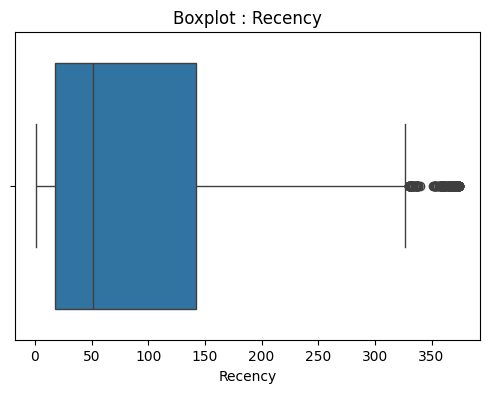

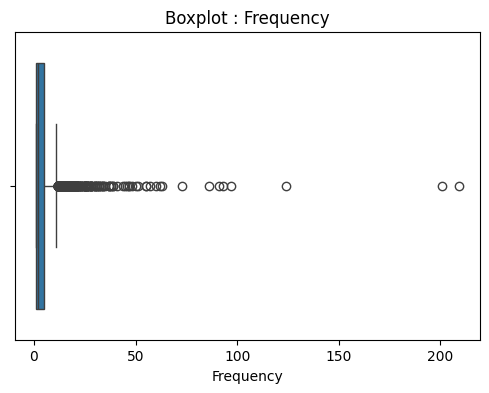

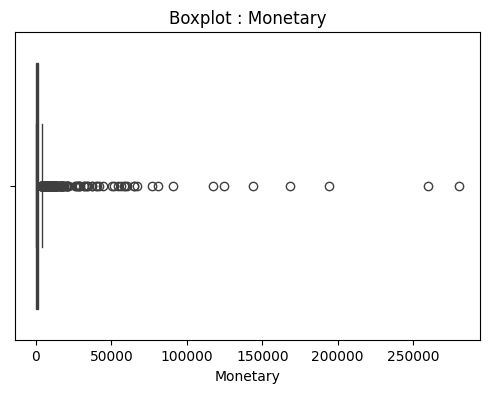

In [19]:
numeric_cols = df_rfm.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df_rfm[col])
    plt.title(f"Boxplot : {col}")
    plt.xlabel(col)
    plt.show()

In [20]:
def cap_outliers_iqr(df, column):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df.loc[df[column] < lower_bound, column] = lower_bound
    df.loc[df[column] > upper_bound, column] = upper_bound

    return df
df_rfm = df_rfm.dropna(subset=["CustomerID"])
df_rfm = cap_outliers_iqr(df_rfm, "Recency")
df_rfm = cap_outliers_iqr(df_rfm, "Frequency")
df_rfm = cap_outliers_iqr(df_rfm, "Monetary")

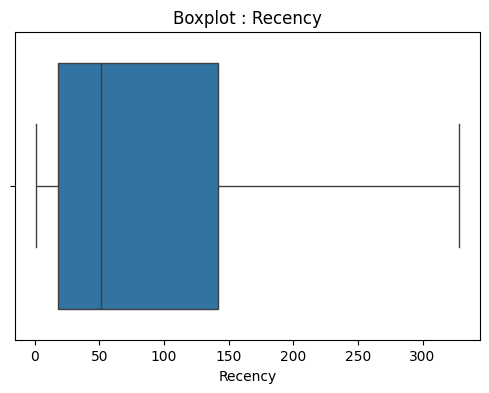

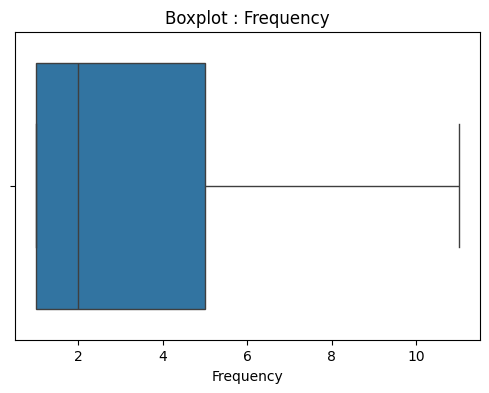

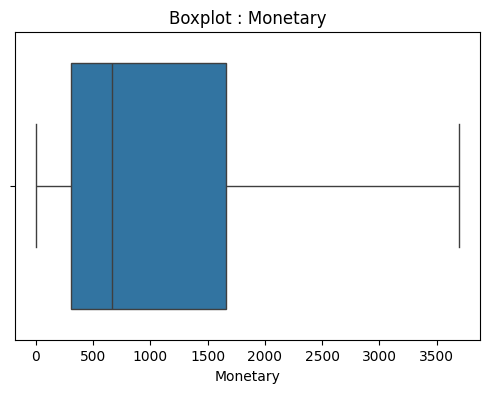

In [21]:
numeric_cols = df_rfm.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df_rfm[col])
    plt.title(f"Boxplot : {col}")
    plt.xlabel(col)
    plt.show()

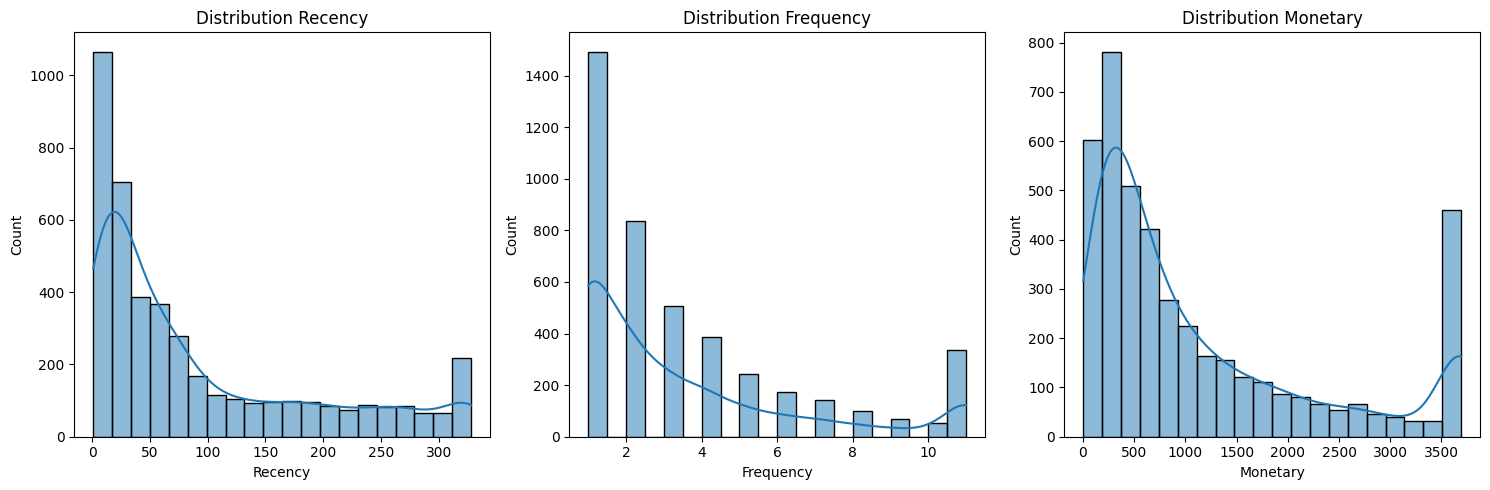

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.histplot(df_rfm['Recency'], bins=20, kde=True, ax=axes[0])
axes[0].set_title("Distribution Recency")

sns.histplot(df_rfm['Frequency'], bins=20, kde=True, ax=axes[1])
axes[1].set_title("Distribution Frequency")

sns.histplot(df_rfm['Monetary'], bins=20, kde=True, ax=axes[2])
axes[2].set_title("Distribution Monetary")

plt.tight_layout()
plt.savefig('image/rfm_distributions.png')
plt.show()

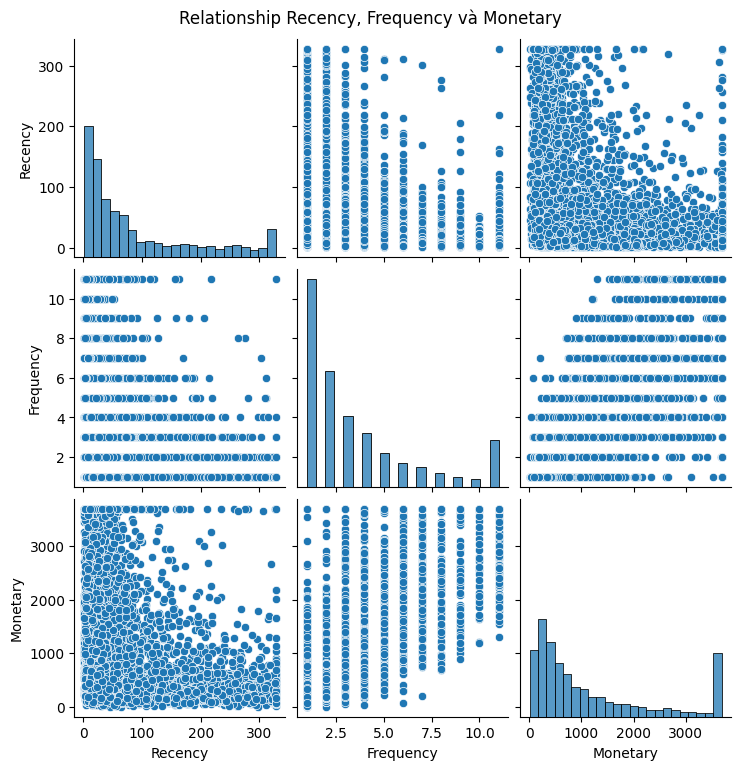

In [23]:
sns.pairplot(df_rfm[['Recency', 'Frequency', 'Monetary']])
plt.suptitle("Relationship Recency, Frequency và Monetary", y=1.02)
plt.savefig('image/rfm_pairplot.png')
plt.show()

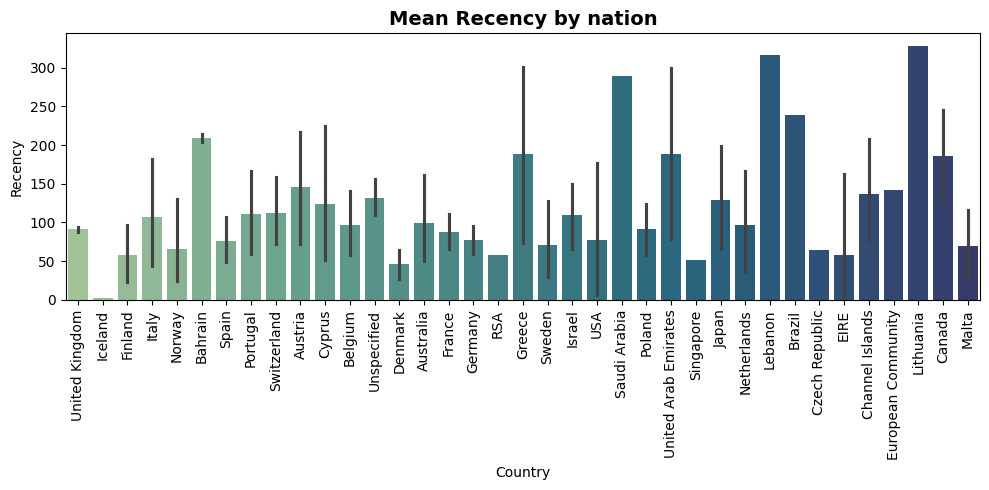

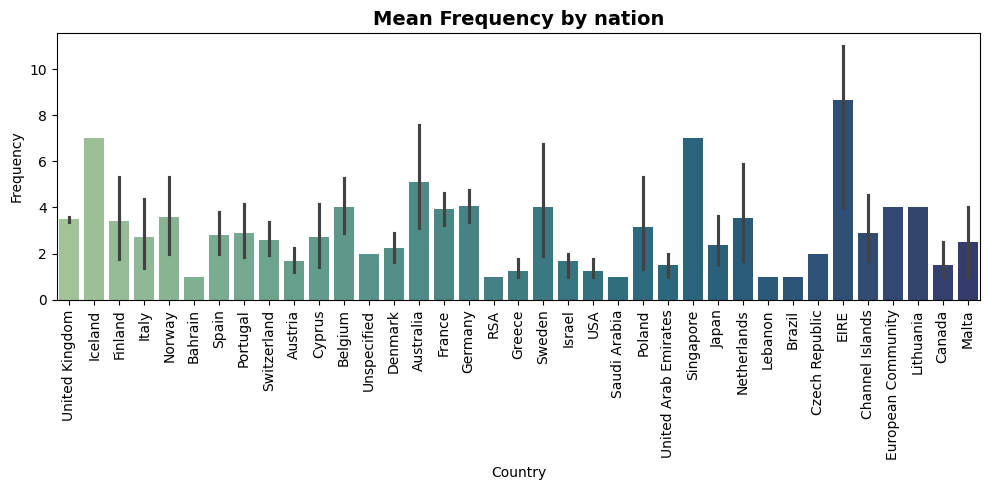

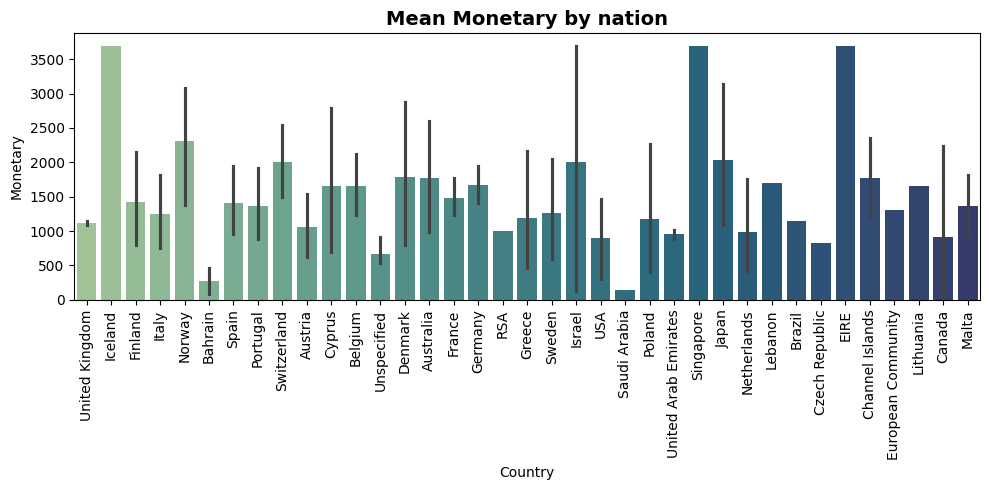

In [24]:
metrics = ['Recency', 'Frequency', 'Monetary']

for metric in metrics:
    plt.figure(figsize=(10, 5))
    sns.barplot(data=df_rfm, x='Country', y=metric, palette='crest')
    plt.title(f"Mean {metric} by nation", fontsize=14, fontweight='bold')
    plt.xticks(rotation=90)
    plt.ylabel(metric)
    plt.xlabel("Country")
    plt.tight_layout()
    plt.show()

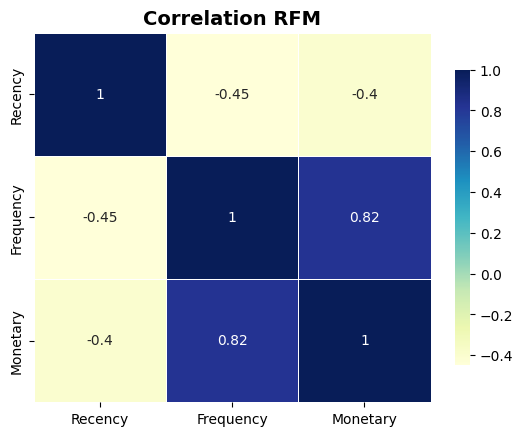

In [25]:
sns.heatmap(
    df_rfm[['Recency', 'Frequency', 'Monetary']].corr(),
    annot=True,
    cmap='YlGnBu',
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title("Correlation RFM", fontsize=14, fontweight='bold')
plt.savefig('image/rfm_correlation.png')
plt.show()

# scale data

In [26]:
feature = ['Recency', 'Frequency', 'Monetary']
X = df_rfm[feature]

from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X)

In [27]:
X_scaled_df = pd.DataFrame(X_scaled, columns=numeric_cols)
X_scaled_df.head()

,Recency,Frequency,Monetary
0,2.413382,-0.818035,2.208843
1,-0.920352,1.155805,2.208843
2,-0.169233,0.168885,0.556606
3,-0.745433,-0.818035,0.521992
4,2.248753,-0.818035,-0.719151


# Kmean

k_best = 5


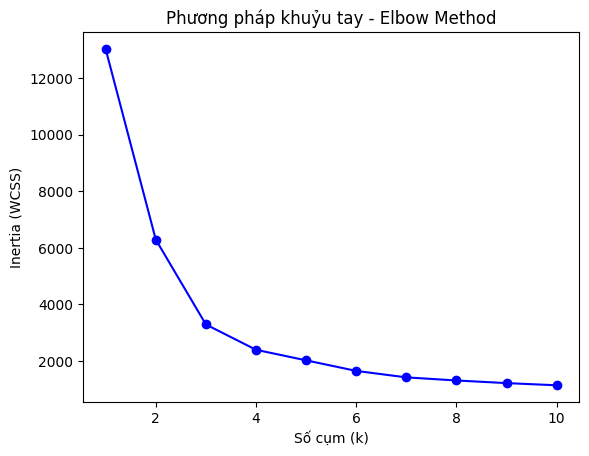

In [28]:
from sklearn.cluster import KMeans

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

diff1 = np.diff(inertia)
diff2 = np.diff(diff1)
k_opt = np.argmin(diff2) + 2
print(f"k_best = {k_opt}")


plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Số cụm (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Phương pháp khuỷu tay - Elbow Method')
plt.show()

In [29]:
kmeans = KMeans(n_clusters=k_opt, random_state=42)
df_rfm['Cluster'] = kmeans.fit_predict(X_scaled)

df_rfm.head()

,CustomerID,Recency,Frequency,Monetary,Country,Cluster
0,12346.0,326,1,3691.77,United Kingdom,2
1,12347.0,2,7,3691.77,Iceland,1
2,12348.0,75,4,1797.24,Finland,3
3,12349.0,19,1,1757.55,Italy,0
4,12350.0,310,1,334.40,Norway,2


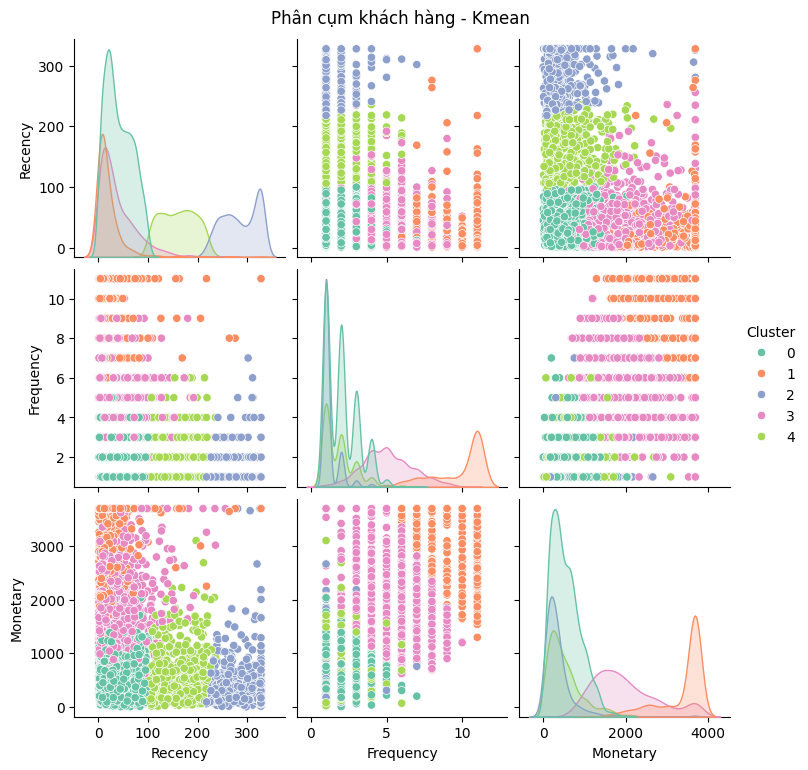

In [30]:
sns.pairplot(df_rfm, vars=feature, hue='Cluster', palette='Set2', diag_kind='kde')
plt.suptitle('Phân cụm khách hàng - Kmean', y=1.02)
plt.show()

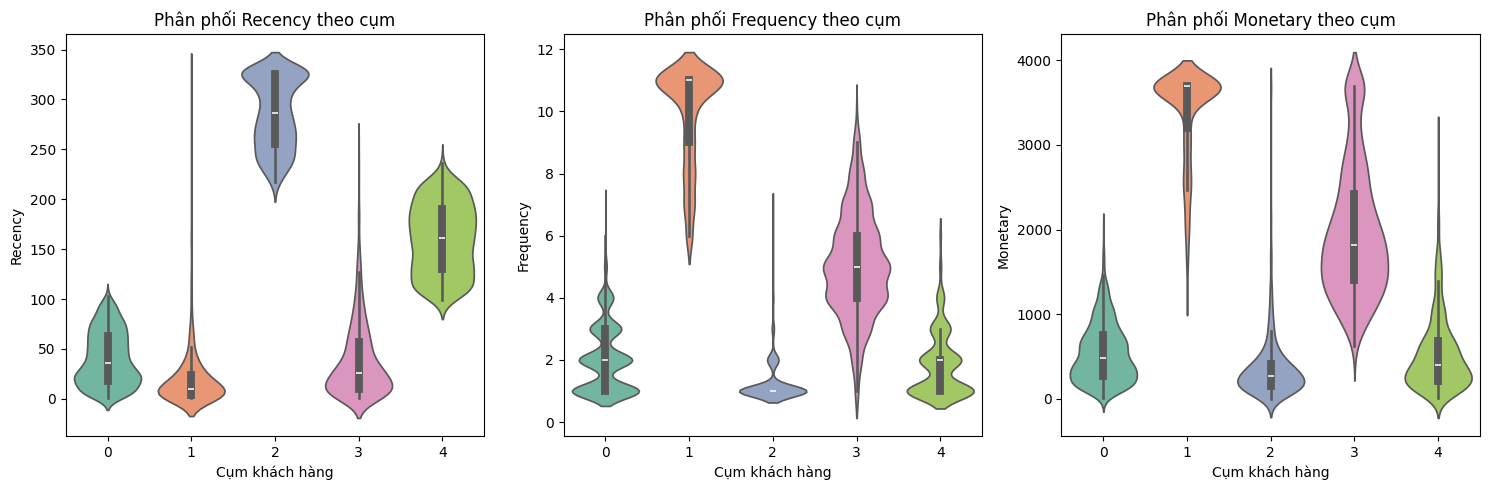

In [31]:
plt.figure(figsize=(15, 5))

for i, col in enumerate(feature):
    plt.subplot(1, 3, i + 1)
    sns.violinplot(data=df_rfm, x='Cluster', y=col, palette='Set2')
    plt.title(f'Phân phối {col} theo cụm')
    plt.xlabel('Cụm khách hàng')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

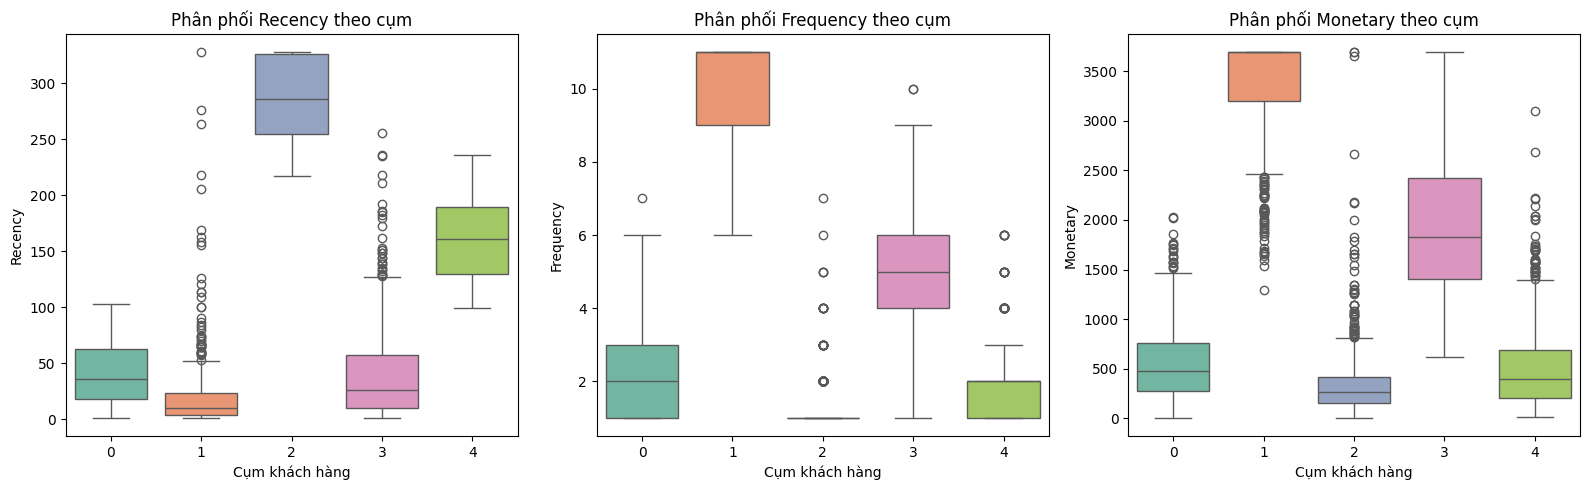

In [32]:
plt.figure(figsize=(16,5))

# Recency
plt.subplot(1,3,1)
sns.boxplot(data=df_rfm, x='Cluster', y='Recency', palette='Set2')
plt.title('Phân phối Recency theo cụm')
plt.xlabel('Cụm khách hàng')
plt.ylabel('Recency')

# Frequency
plt.subplot(1,3,2)
sns.boxplot(data=df_rfm, x='Cluster', y='Frequency', palette='Set2')
plt.title('Phân phối Frequency theo cụm')
plt.xlabel('Cụm khách hàng')
plt.ylabel('Frequency')

# Monetary
plt.subplot(1,3,3)
sns.boxplot(data=df_rfm, x='Cluster', y='Monetary', palette='Set2')
plt.title('Phân phối Monetary theo cụm')
plt.xlabel('Cụm khách hàng')
plt.ylabel('Monetary')

plt.tight_layout()
plt.show()

| Cụm Khách hàng | Recency | Frequency | Monetary | Tên đề xuất | Mô tả tổng quát | Insight chính | Chiến lược |
|----------------|---------|-----------|-----------|--------------|------------------|--------------------|------------------------|
| 0 | Thấp - Trung bình (Mua tương đối gần đây) | Rất thấp | Rất thấp | **Khách hàng Mới/Thử nghiệm** | Mới mua lần đầu hoặc mua thử. | Nhóm đang trong giai đoạn "cửa sổ vàng" để biến thành khách trung thành. | Gửi email chào mừng, ưu đãi đơn hàng 2, gợi ý sản phẩm phù hợp, remarketing nhẹ. |
| 1 | Rất thấp (Mua gần đây) | Rất cao | Cao - Rất cao | **Khách hàng VIP/Siêu trung thành** | Nhóm giá trị nhất, mua thường xuyên và chi tiêu lớn. | Đóng góp lớn vào doanh thu, rất nhạy với trải nghiệm và sự quan tâm cá nhân hóa. | Ưu đãi VIP, chương trình thành viên cấp cao, quà tặng sinh nhật, ưu tiên chăm sóc. |
| 2 | Rất cao (Mua rất lâu) | Rất thấp | Rất thấp | **Khách hàng Mất hoạt động/Ngủ đông** | Không còn mua sắm, gần như rời bỏ. | ROI thấp nếu đầu tư chăm sóc mạnh, khả năng quay lại thấp. | Remarketing chi phí thấp, email khuyến mãi mạnh, chiến dịch “winback” 1 lần. |
| 3 | Thấp - Trung bình | Trung bình - Khá | Trung bình - Cao | **Khách hàng Trung thành/Ổn định** | Mua đều đặn, chi tiêu ổn. | Nhóm tiềm năng để nâng cấp thành VIP nếu chăm sóc tốt. | Chương trình tích điểm, ưu đãi duy trì, khảo sát trải nghiệm, upsell nhẹ. |
| 4 | Trung bình - Cao (Mua khá lâu) | Rất thấp | Rất thấp | **Khách hàng Có nguy cơ rời bỏ (At-Risk)** | Đã lâu không mua và chi tiêu giảm. | Dấu hiệu bắt đầu rời bỏ, vẫn còn cơ hội giữ chân nếu hành động đúng lúc. | Gửi thông điệp cá nhân hóa, mã giảm giá, nhắc sản phẩm yêu thích, lý do quay lại. |


# HierarchicalClustering

In [33]:
df_hc = df_rfm[['CustomerID','Recency', 'Frequency', 'Monetary','Country']]
from scipy.cluster import hierarchy
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

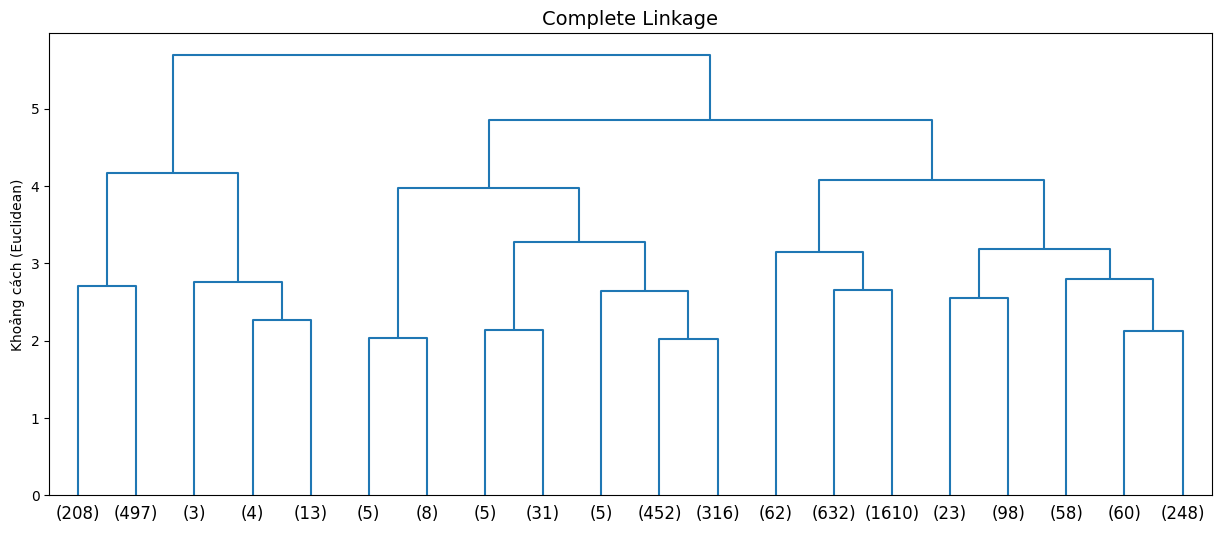

In [34]:
plt.figure(figsize=(15, 6))
Z_complete = hierarchy.linkage(X_scaled, method='complete')

hierarchy.dendrogram(
    Z_complete,
    truncate_mode='lastp',
    p=20,
    color_threshold=0
)

plt.title('Complete Linkage', fontsize=14)
plt.ylabel('Khoảng cách (Euclidean)')
plt.show()

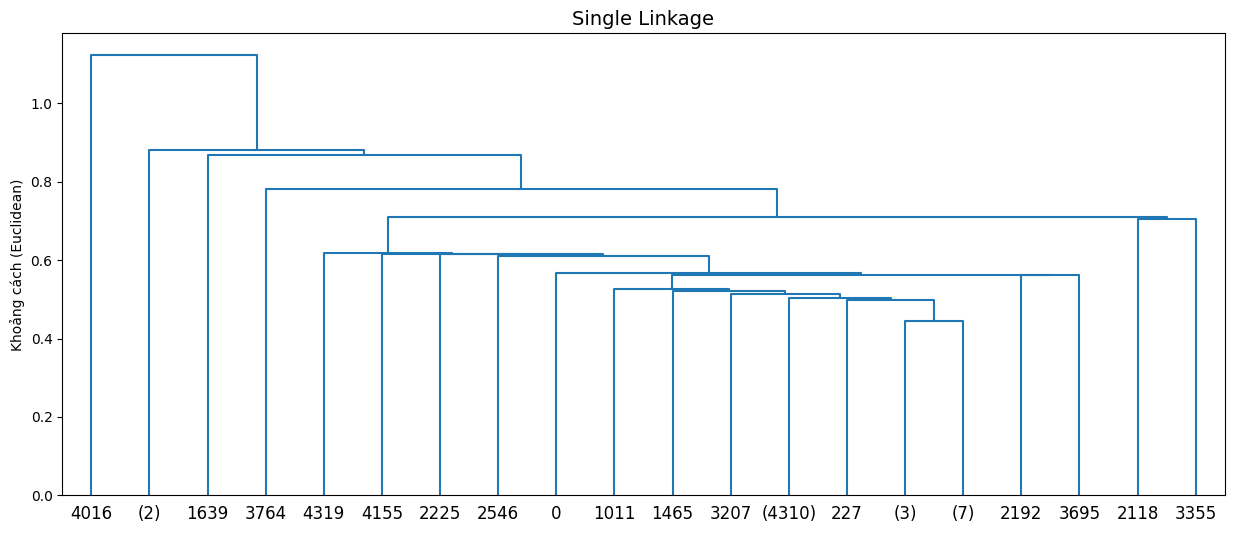

In [35]:
# Single Linkage
plt.figure(figsize=(15, 6))
Z_single = hierarchy.linkage(X_scaled, method='single')

hierarchy.dendrogram(
    Z_single,
    truncate_mode='lastp',
    p=20,
    color_threshold=0
)

plt.title('Single Linkage', fontsize=14)
plt.ylabel('Khoảng cách (Euclidean)')
plt.show()

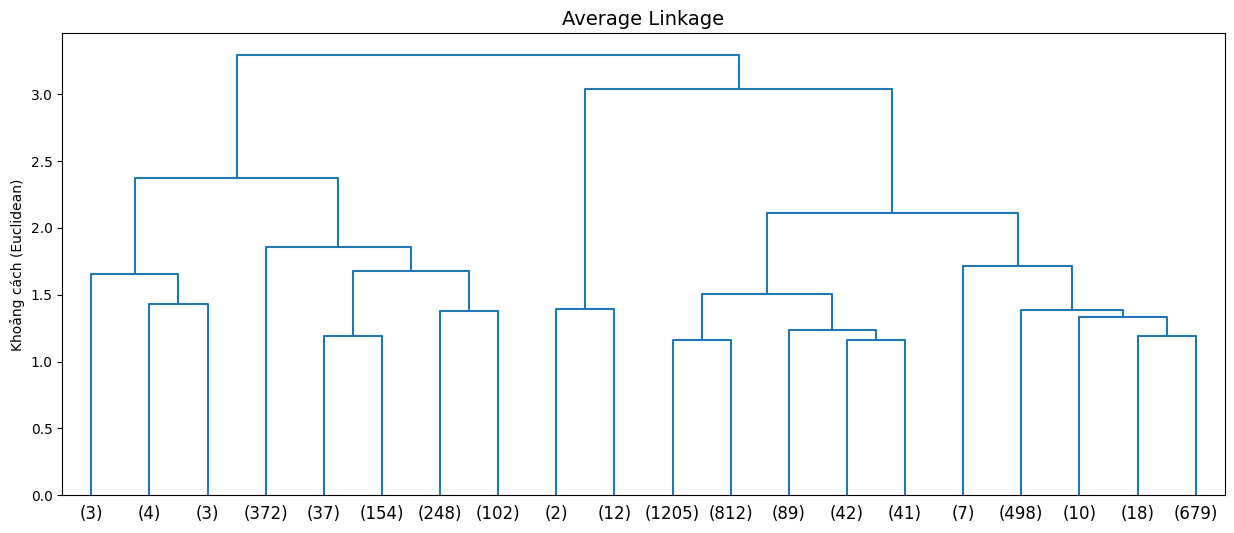

In [36]:
# Average Linkage
plt.figure(figsize=(15, 6))
Z_average = hierarchy.linkage(X_scaled, method='average')

hierarchy.dendrogram(
    Z_average,
    truncate_mode='lastp',
    p=20,
    color_threshold=0
)

plt.title('Average Linkage', fontsize=14)
plt.ylabel('Khoảng cách (Euclidean)')
plt.show()

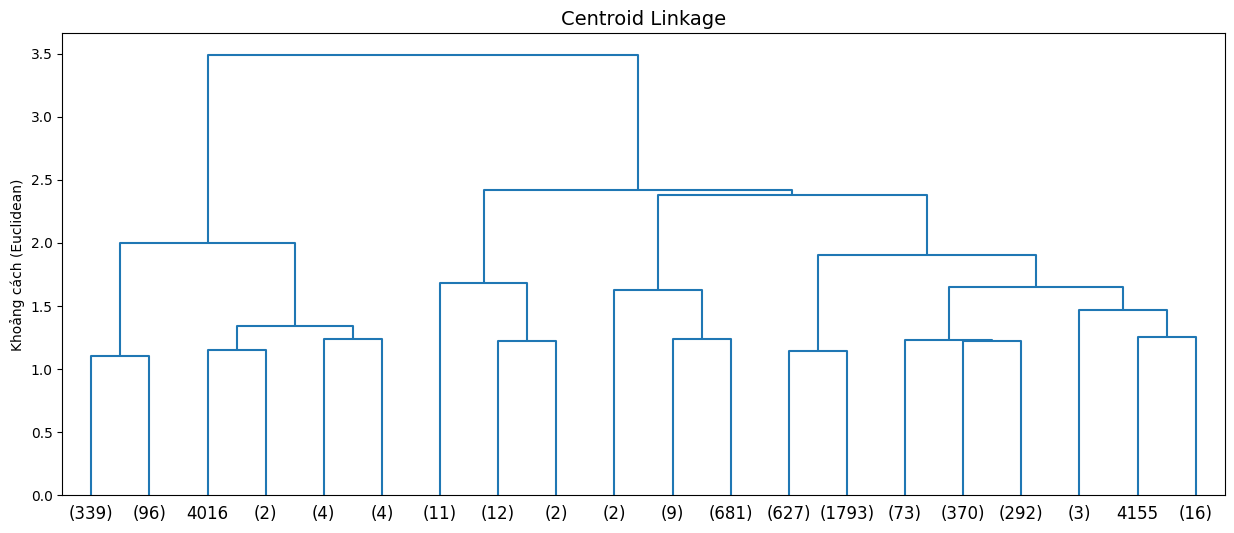

In [37]:
# Centroid Linkage
plt.figure(figsize=(15, 6))
Z_centroid = hierarchy.linkage(X_scaled, method='centroid')

hierarchy.dendrogram(
    Z_centroid,
    truncate_mode='lastp',
    p=20,
    color_threshold=0
)

plt.title('Centroid Linkage', fontsize=14)
plt.ylabel('Khoảng cách (Euclidean)')
plt.show()

In [38]:
from scipy.cluster.hierarchy import fcluster

k=5 # clusters
clusters = fcluster(Z_average, t=k, criterion='maxclust')

df_hc['Cluster_HC'] = clusters
df_hc.head()

,CustomerID,Recency,Frequency,Monetary,Country,Cluster_HC
0,12346.0,326,1,3691.77,United Kingdom,3
1,12347.0,2,7,3691.77,Iceland,2
2,12348.0,75,4,1797.24,Finland,4
3,12349.0,19,1,1757.55,Italy,4
4,12350.0,310,1,334.40,Norway,5


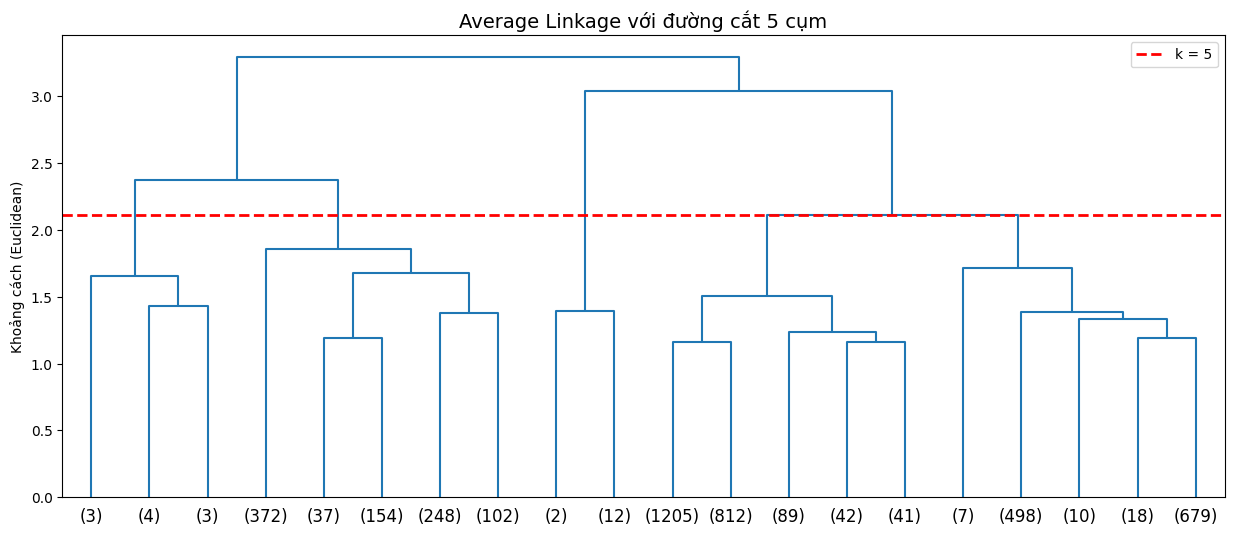

In [39]:
plt.figure(figsize=(15, 6))
dendrogram(Z_average, truncate_mode='lastp', p=20, color_threshold=0)

threshold = Z_average[-k+1, 2]  
plt.axhline(y=threshold, color='red', linestyle='--', linewidth=2, label=f'k = {k}')

plt.title('Average Linkage với đường cắt 5 cụm', fontsize=14)
plt.ylabel('Khoảng cách (Euclidean)')
plt.legend()
plt.show()

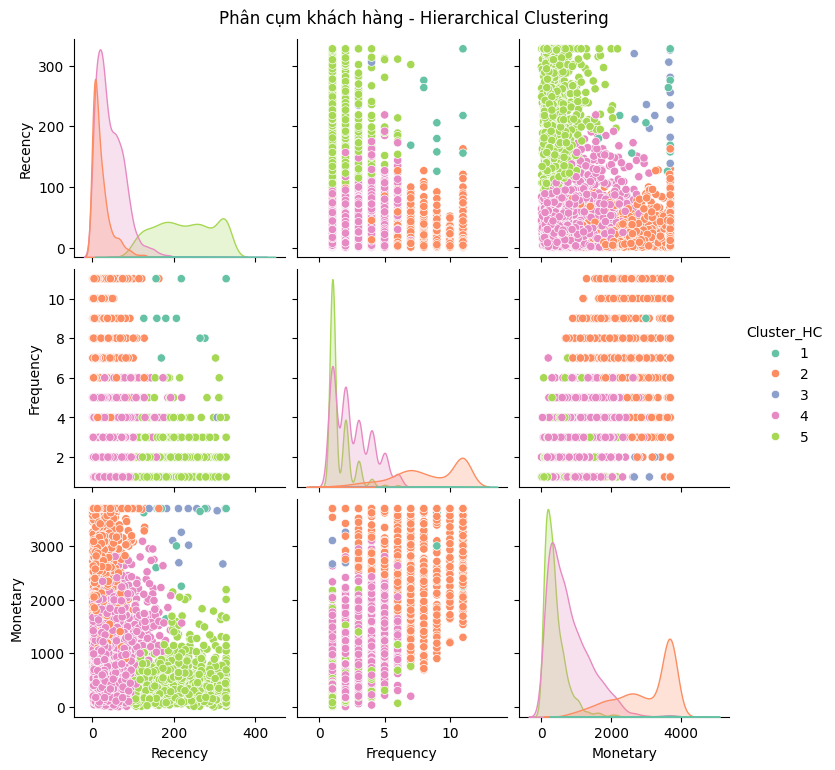

In [40]:
sns.pairplot(df_hc, vars=feature, hue='Cluster_HC', palette='Set2', diag_kind='kde')
plt.suptitle('Phân cụm khách hàng - Hierarchical Clustering', y=1.02)
plt.show()

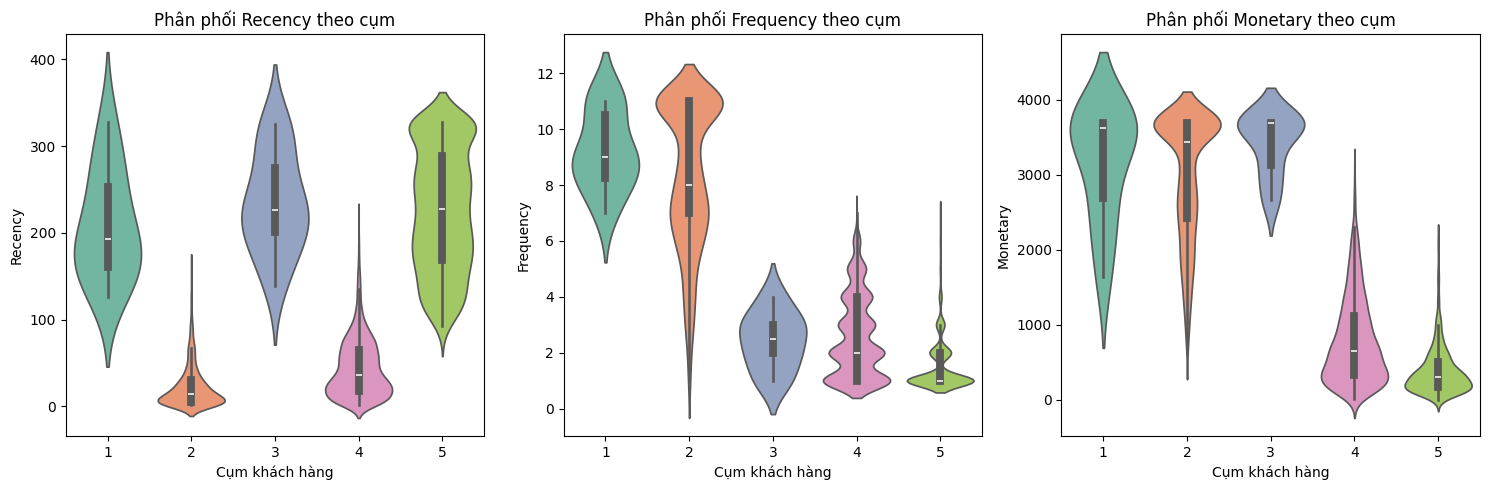

In [41]:
plt.figure(figsize=(15, 5))

for i, col in enumerate(feature):
    plt.subplot(1, 3, i + 1)
    sns.violinplot(data=df_hc, x='Cluster_HC', y=col, palette='Set2')
    plt.title(f'Phân phối {col} theo cụm')
    plt.xlabel('Cụm khách hàng')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

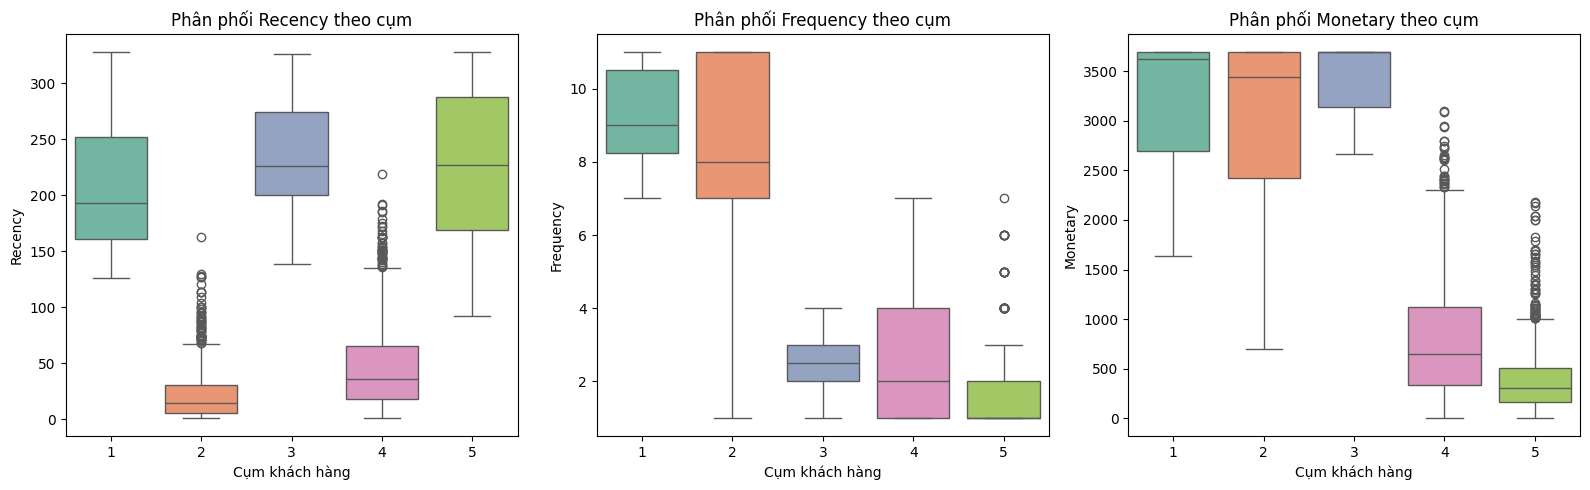

In [42]:
plt.figure(figsize=(16,5))

# Recency
plt.subplot(1,3,1)
sns.boxplot(data=df_hc, x='Cluster_HC', y='Recency', palette='Set2')
plt.title('Phân phối Recency theo cụm')
plt.xlabel('Cụm khách hàng')
plt.ylabel('Recency')

# Frequency
plt.subplot(1,3,2)
sns.boxplot(data=df_hc, x='Cluster_HC', y='Frequency', palette='Set2')
plt.title('Phân phối Frequency theo cụm')
plt.xlabel('Cụm khách hàng')
plt.ylabel('Frequency')

# Monetary
plt.subplot(1,3,3)
sns.boxplot(data=df_hc, x='Cluster_HC', y='Monetary', palette='Set2')
plt.title('Phân phối Monetary theo cụm')
plt.xlabel('Cụm khách hàng')
plt.ylabel('Monetary')

plt.tight_layout()
plt.show()

| Cụm Khách hàng | Recency | Frequency | Monetary | Tên đề xuất | Mô tả tổng quát | **Insight chính** | **Chiến lược gợi ý** |
|----------------|---------|-----------|----------|--------------|------------------|--------------------|------------------------|
| 1 | Cao - Rất Cao (Mua rất lâu) | Rất cao (Tần suất rất cao) | Cao - Rất cao | **Khách hàng Trung thành cũ** | Từng mua rất nhiều nhưng đã ngưng hoạt động lâu. | Khách hàng chất lượng cao nhưng đang rời bỏ. Cần tác động cảm xúc để kéo lại. | Chiến dịch tái kích hoạt VIP, email cảm ơn đặc biệt, ưu đãi lớn cho lần quay lại, thư “chúng tôi nhớ bạn”. |
| 2 | Thấp (Mua gần đây) | Rất cao | Cao - Rất cao | **Khách hàng Trung thành / VIP hiện tại** | Nhóm giá trị nhất: mua gần đây, thường xuyên, chi tiêu cao. | Nguồn doanh thu cốt lõi, cần giữ bằng trải nghiệm vượt trội. | Ưu đãi độc quyền, quà tri ân, chương trình VIP, khuyến khích giới thiệu bạn bè (referral). |
| 3 | Cao - Rất Cao (Mua rất lâu) | Thấp | Rất cao | **Khách hàng Lớn đã ngủ quên** | Từng là khách chi tiêu lớn nhưng biến mất lâu. | Giá trị cao nhưng rủi ro mất hoàn toàn nếu không kích hoạt. | Thư cá nhân hóa, ưu đãi đặc biệt (high-value), quà cảm ơn, gọi chăm sóc (nếu áp dụng). |
| 4 | Cao - Rất Cao (Mua rất lâu) | Rất thấp | Rất thấp | **Khách hàng Mất hoạt động/Ngủ đông** | Đã ngừng mua từ lâu, chi tiêu thấp. | Khả năng quay lại thấp → không nên đầu tư mạnh. | Remarketing nhẹ, email chu kỳ thấp, ưu đãi chỉ khi có chiến dịch mở rộng. |
| 5 | Thấp - Trung bình | Thấp | Trung bình - Thấp | **Khách hàng Tiềm năng cần kích hoạt** | Đã từng mua và chi tiêu khá nhưng không thường xuyên. | Tệp có tiềm năng lớn nếu tăng tần suất. | Gợi ý sản phẩm cá nhân hóa, combo giảm giá, ưu đãi lần tiếp theo, remarketing theo hành vi. |


In [43]:
df_hc['Cluster_RFM'] = df_rfm['Cluster'].values
res = pd.crosstab(df_hc['Cluster_RFM'], df_hc['Cluster_HC'])

res

Cluster_HC,1,2,3,4,5
Cluster_RFM,,,,,
0,0,0,0,1653,12
1,9,558,0,0,0
2,0,0,4,0,626
3,1,355,8,456,0
4,0,0,2,80,574


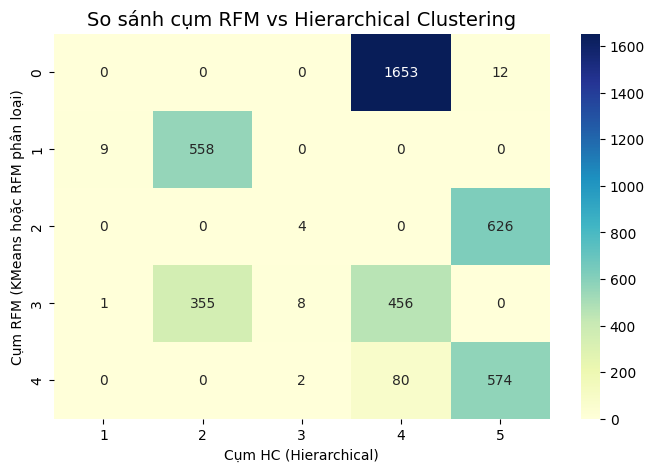

In [44]:
plt.figure(figsize=(8, 5))
sns.heatmap(res, annot=True, fmt='d', cmap='YlGnBu')

plt.title('So sánh cụm RFM vs Hierarchical Clustering', fontsize=14)
plt.xlabel('Cụm HC (Hierarchical)')
plt.ylabel('Cụm RFM (KMeans hoặc RFM phân loại)')
plt.show()

In [45]:
#end